<a href="https://colab.research.google.com/github/zuzannagr05/lecture1/blob/main/PUM10_systemy_rekomendacyjne_cz2_todo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dane https://grouplens.org/datasets/movielens/32m/


In [9]:

ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())
movies = pd.read_csv('/content/movies.csv')


   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858


Wczytanie plikow z selekcja uzytkownikow - tylko dla cwiczenia cz2. w celu redukcji danych

In [10]:
import pandas as pd

ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())

movies = pd.read_csv('/content/movies.csv')

# policz liczbę ocen na użytkownika
user_activity = ratings['userId'].value_counts()

# wybierz 100 najbardziej aktywnych użytkowników
top_users = user_activity.head(100).index

# przefiltruj dane
ratings = ratings[ratings['userId'].isin(top_users)]

# opcjonalnie sprawdź wynik
print("Liczba rekordów po filtracji:", len(ratings))
print("Liczba użytkowników:", ratings['userId'].nunique())


   userId  movieId  rating    timestamp
0       1       17     4.0  944249077.0
1       1       25     1.0  944250228.0
2       1       29     2.0  943230976.0
3       1       30     5.0  944249077.0
4       1       32     5.0  943228858.0
Liczba rekordów po filtracji: 144381
Liczba użytkowników: 100


Poznaj dane:


1.   Ile jest ocen filmów?
2.   Ile filmów w bazie?
3.   Ile użytkowników?
4.   Jaka jest średnia liczba ocen na użytkownika i na film?



In [11]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
#n_movies = movies['movieId'].nunique()
n_users = len(ratings['userId'].unique())

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings/n_movies, 2)}")

Number of ratings: 144381
Number of unique movieId's: 20319
Number of unique users: 100
Average number of ratings per user: 1443.81
Average number of ratings per movie: 7.11


Jak wygląda rozkład ocen filmów?




/tmp/ipykernel_500/2038653828.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=ratings, palette="viridis")


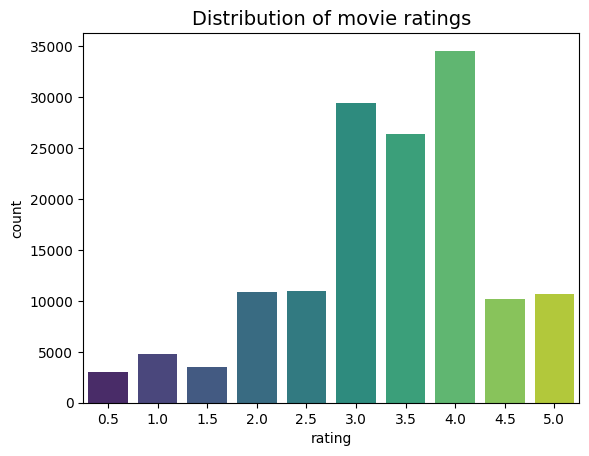

In [12]:
sns.countplot(x="rating", data=ratings, palette="viridis")
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()

In [13]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings['title'].value_counts()[0:10]

,count
title,
Back to the Future (1985),95
"Silence of the Lambs, The (1991)",95
Forrest Gump (1994),95
"Matrix, The (1999)",94
Pulp Fiction (1994),93
Seven (a.k.a. Se7en) (1995),92
"Shawshank Redemption, The (1994)",92
Groundhog Day (1993),92
"Sixth Sense, The (1999)",92


In [14]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")

mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean global rating: 3.32.
Mean rating per user: 3.35.


In [15]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
print(movies[movies['movieId']==lowest_rated])
highest_rated = mean_ratings['rating'].idxmax()
print(movies[movies['movieId'] == highest_rated])

     movieId           title        genres
848      867  Carpool (1996)  Comedy|Crime
     movieId                                              title       genres
358      363  Wonderful, Horrible Life of Leni Riefenstahl, ...  Documentary


In [16]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
358,363,"Wonderful, Horrible Life of Leni Riefenstahl, ...",Documentary


In [17]:
movie_stats = ratings.groupby('movieId')[['rating']].agg(['count', 'mean'])
movie_stats.columns = movie_stats.columns.droplevel()

In [18]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

def bayesian_avg(ratings):
    bayesian_avg = (C*m+ratings.sum())/(C+ratings.count())
    return bayesian_avg

bayesian_avg_ratings = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']

movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')
movie_stats.describe()

,movieId,count,mean,bayesian_avg
count,20319.000000,20319.000000,20319.000000,20319.000000
mean,90425.344505,7.105714,3.063920,3.104145
std,83185.092714,12.573127,0.914835,0.250276
min,1.000000,1.000000,0.500000,1.853768
25%,6238.500000,1.000000,2.550000,2.956616
50%,74948.000000,2.000000,3.250000,3.117719
75%,157465.000000,7.000000,3.650000,3.241089
max,292467.000000,95.000000,5.000000,4.207286


In [19]:
movie_ratings['movieId'].nunique()
M = movie_ratings['userId'].nunique()
user_mapper = dict(zip(np.unique(movie_ratings["userId"]), list(range(M))))

In [20]:
from scipy.sparse import csr_matrix

def create_sparse(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['userId'].nunique()
    N = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movieId"])))

    user_index = [user_mapper[i] for i in df['userId']]
    item_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (user_index, item_index)), shape=(M,N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_sparse(ratings)

In [21]:
sparsity = X.count_nonzero()/(X.shape[0]*X.shape[1])

print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 7.11%


Wykorzystaj algorytm najblizszych sąsiadów, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

In [22]:
from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, k, metric='cosine', show_distance=False):
    """
    Finds k-nearest neighbours for a given movie id.

    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations

    Returns:
        list of k similar movie ID's
    """
    neighbour_ids = []

    # Transpose the user-item matrix X to an item-user matrix X_movies
    # Now, each row in X_movies corresponds to a movie, and columns to users
    X_movies = X.T

    # Get the internal index for the movie_id from movie_mapper
    # This index is a row index in X_movies
    target_movie_idx = movie_mapper[movie_id]

    # Extract the vector for the target movie from X_movies
    target_movie_vec = X_movies[target_movie_idx]

    # Initialize kNN model. k+1 because the movie itself will be the closest neighbor
    kNN = NearestNeighbors(n_neighbors=k+1, algorithm="brute", metric=metric)
    kNN.fit(X_movies) # Fit the model on the movie-user matrix

    # Reshape movie_vec if it's a 1D array to a 2D array for kneighbors
    if isinstance(target_movie_vec, (np.ndarray)):
        target_movie_vec = target_movie_vec.reshape(1,-1)

    # Find k+1 nearest neighbors (distances and indices)
    if show_distance:
        distances, indices = kNN.kneighbors(target_movie_vec, return_distance=True)
    else:
        indices = kNN.kneighbors(target_movie_vec, return_distance=False)

    # Iterate through the neighbors, skipping the first one (the movie itself)
    for i in range(1, len(indices[0])):
        # 'idx' is the internal index of the similar movie in the sparse matrix
        idx = indices[0][i]
        # Map this internal index back to the original movieId using movie_inv_mapper
        neighbour_ids.append(movie_inv_mapper[idx])

    return neighbour_ids

In [23]:
movie_titles = dict(zip(movies['movieId'], movies['title']))
movie_id = 1

similar_ids = find_similar_movies(movie_id, X, k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}")
for i in similar_ids:
    print(movie_titles[i])

Because you watched Toy Story (1995)
Back to the Future (1985)
Forrest Gump (1994)
Shrek (2001)
Toy Story 2 (1999)
Finding Nemo (2003)
Truman Show, The (1998)
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)
Lord of the Rings: The Fellowship of the Ring, The (2001)
Jurassic Park (1993)
Men in Black (a.k.a. MIB) (1997)


Wykorzystaj algorytm SVD, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

cz1: klasyczne SVD (biblioteka **NumPy**)

In [30]:
import numpy as np

def svd_reconstruct(R, k=2):
    """
    Aproksymacja macierzy przez klasyczne SVD
    R: macierz wejściowa (pełna, numpy array)
    k: liczba składowych do wykorzystania
    """
    U, s, Vt = np.linalg.svd(R, full_matrices=False)

    # Truncate to k components
    s_k = np.diag(s[:k])
    U_k = U[:, :k]
    Vt_k = Vt[:k, :]

    R_approx = U_k @ s_k @ Vt_k

    return R_approx

cz2: TruncatedSVD (scikit-learn)


In [31]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

def truncated_svd_reconstruct(R, k=2):
    """
    Aproksymacja macierzy przez TruncatedSVD (sklearn)
    R: macierz wejściowa (sparse matrix)
    k: liczba składowych do wykorzystania
    """
    svd = TruncatedSVD(n_components=k)
    svd.fit(R)
    R_reduced = svd.transform(R)
    R_approx = svd.inverse_transform(R_reduced)

    return R_approx

wywołaj obie funkcje i stworz rekomentacje dla uzytkownika nr 10

In [51]:
print("Available User IDs:")
print(list(user_mapper.keys()))

Available User IDs:
[np.int64(28), np.int64(188), np.int64(265), np.int64(328), np.int64(337), np.int64(354), np.int64(360), np.int64(430), np.int64(447), np.int64(527), np.int64(547), np.int64(588), np.int64(655), np.int64(661), np.int64(702), np.int64(909), np.int64(982), np.int64(1025), np.int64(1048), np.int64(1050), np.int64(1057), np.int64(1069), np.int64(1140), np.int64(1306), np.int64(1411), np.int64(1421), np.int64(1522), np.int64(1551), np.int64(1617), np.int64(1629), np.int64(1668), np.int64(1735), np.int64(1739), np.int64(1766), np.int64(1779), np.int64(1783), np.int64(1842), np.int64(1860), np.int64(1920), np.int64(1953), np.int64(2086), np.int64(2112), np.int64(2268), np.int64(2338), np.int64(2364), np.int64(2421), np.int64(2471), np.int64(2529), np.int64(2704), np.int64(2707), np.int64(2741), np.int64(2742), np.int64(2806), np.int64(2810), np.int64(2817), np.int64(2832), np.int64(2844), np.int64(2862), np.int64(3033), np.int64(3038), np.int64(3065), np.int64(3070), np.in

In [50]:
import numpy as np

R_svd_model = svd_reconstruct(X.toarray(), k=20)
R_trunc_model = truncated_svd_reconstruct(X, k=2)

def get_recommendations(R_original, R_pred, user_idx):
    recs = []
    for item_idx in range(R_original.shape[1]):
        if R_original[user_idx, item_idx] == 0:
            movie_id = movie_inv_mapper[item_idx]
            # Clamp predicted ratings to a realistic range (e.g., 0.5 to 5.0)
            predicted_rating = np.clip(R_pred[user_idx, item_idx], 0.5, 5.0)
            recs.append((movie_id, predicted_rating))
    return sorted(recs, key=lambda x: x[1], reverse=True)

# User IDs for which to generate recommendations
target_user_ids = [447, 188]

for user_id_target in target_user_ids:
    try:
        user_idx_target = user_mapper[user_id_target]

        recs_svd_target = get_recommendations(X.toarray(), R_svd_model, user_idx_target)
        recs_trunc_target = get_recommendations(X.toarray(), R_trunc_model, user_idx_target)

        print(f"\nGenerowanie rekomendacji dla użytkownika ID: {user_id_target} (Indeks: {user_idx_target})\n")

        print(f"Top 10 SVD (user_id {user_id_target}):")
        for movie_id, score in recs_svd_target[:10]:
            print(f"{movie_titles[movie_id]} (Przewidywana ocena: {score:.3f})")

        print("-------------------------------")

        print(f"Top 10 Truncated SVD (user_id {user_id_target}, k=2):")
        for movie_id, score in recs_trunc_target[:10]:
            print(f"{movie_titles[movie_id]} (Przewidywana ocena: {score:.3f})")
        print("-------------------------------")

    except KeyError:
        print(f"Użytkownik o ID {user_id_target} nie został znaleziony w dostępnych użytkownikach.")


Generowanie rekomendacji dla użytkownika ID: 447 (Indeks: 8)

Top 10 SVD (user_id 447):
Seven (a.k.a. Se7en) (1995) (Przewidywana ocena: 3.909)
Groundhog Day (1993) (Przewidywana ocena: 3.521)
Die Hard (1988) (Przewidywana ocena: 3.442)
Léon: The Professional (a.k.a. The Professional) (Léon) (1994) (Przewidywana ocena: 3.267)
Donnie Darko (2001) (Przewidywana ocena: 3.209)
Monsters, Inc. (2001) (Przewidywana ocena: 3.194)
Stand by Me (1986) (Przewidywana ocena: 3.143)
Lock, Stock & Two Smoking Barrels (1998) (Przewidywana ocena: 3.095)
Zodiac (2007) (Przewidywana ocena: 3.073)
City of God (Cidade de Deus) (2002) (Przewidywana ocena: 3.057)
-------------------------------
Top 10 Truncated SVD (user_id 447, k=2):
Seven (a.k.a. Se7en) (1995) (Przewidywana ocena: 3.897)
Die Hard (1988) (Przewidywana ocena: 3.582)
Groundhog Day (1993) (Przewidywana ocena: 3.553)
Léon: The Professional (a.k.a. The Professional) (Léon) (1994) (Przewidywana ocena: 3.188)
Back to the Future Part II (1989) (Prz

KLUCZOWA różnica (najważniejsze)
SVD:

* działa na pełnej macierzy
* traktuje brak ocen jako 0 → to jest BŁĄD modelowy

TruncatedSVD:

* działa na macierzy sparse
* ale nadal NIE rozróżnia: brak oceny vs słaba ocena



Ocena modeli - policz RSME na macierzach tylko na niezerowych elementach

In [48]:
import numpy as np
from sklearn.metrics import mean_squared_error

R_original = X.toarray()

mask = R_original > 0

actual_ratings = R_original[mask]

pred_svd_ratings = R_svd[mask]
pred_trunc_ratings = R_trunc[mask]

rmse_svd = np.sqrt(mean_squared_error(actual_ratings, pred_svd_ratings))
rmse_trunc = np.sqrt(mean_squared_error(actual_ratings, pred_trunc_ratings))

print(f"RMSE dla klasycznego SVD: {rmse_svd:.4f}")
print(f"RMSE dla TruncatedSVD: {rmse_trunc:.4f}")

RMSE dla klasycznego SVD: 1.7171
RMSE dla TruncatedSVD: 1.7146
